In [190]:
import numpy as np
import matplotlib.pyplot as plt

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100


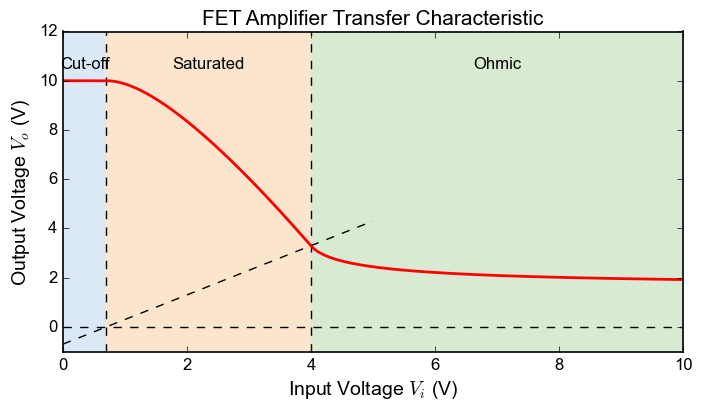

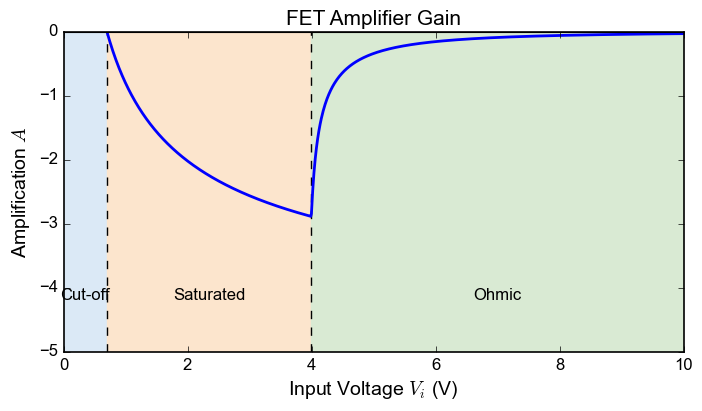

In [ ]:
Vdd = 10
Rd = 5000
Rs = 1000
Vt = 0.7
alpha = 0.0007
Vimax = Vt + (-Rd + Rs*(Rd + Rs)*alpha*Vdd + Rd*np.sqrt(1 + 2 * alpha * Vdd*(Rd + Rs))) / (alpha*(Rd + Rs)**2)



Vi = np.linspace(0, 10, 1000)

Vo = np.empty_like(Vi)

mask_low = Vi < Vt
mask_mid = (Vi >= Vt) & (Vi < Vimax)
mask_high = Vi >= Vimax

Vo[mask_low] = Vdd
Vo[mask_mid] = Vdd - Rd/(alpha*Rs**2) *((Vi[mask_mid] - Vt)*alpha*Rs + 1 - np.sqrt(1 + 2 * alpha * Rs * (Vi[mask_mid] - Vt)))
Vo[mask_high] = (
    Rd
    - Rs**2 * Vdd * alpha
    + Rd * Rs * (Vi[mask_high] - Vt) * alpha
    - Rd**2
    * (
        -Vi[mask_high] * alpha
        + Vt * alpha
        + np.sqrt(
            (1 / Rd**2)
            * (
                1
                + alpha
                * (
                    -2 * Rd * Vdd
                    + 2 * Rd * Vi[mask_high]
                    + 2 * Rs * Vi[mask_high]
                    - 2 * (Rd + Rs) * Vt
                    + (
                        Rd * (-Vi[mask_high] + Vt)
                        + Rs * (Vdd - Vi[mask_high] + Vt)
                    )**2
                    * alpha
                )
            )
        )
    )
) / ((Rd - Rs) * (Rd + Rs) * alpha)


plt.figure(figsize=(8,4))
plt.axvspan(0, Vt, color='#dbe9f6')
plt.axvspan(Vt, Vimax, color='#fce5cd')
plt.axvspan(Vimax, 10, color='#d9ead3')
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot([0, 5], [-Vt, 5 - Vt], color='black', linestyle='--', linewidth=1)
plt.plot(Vi, Vo, lw=2, color='red', zorder=2)
plt.text(Vt / 2, 11, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, 11, 'Saturated', ha='center', va='top')
plt.text((Vimax + 10) / 2, 11, 'Ohmic', ha='center', va='top')
plt.xlabel(r'Input Voltage $V_i$ (V)', fontsize=14)
plt.ylabel(r'Output Voltage $V_o$ (V)', fontsize=14)
plt.xlim(0, 10)
plt.ylim(-1, 12)
plt.title('FET Amplifier Transfer Characteristic', fontsize=15)
# plt.savefig("amplifier-02-volt.eps", format='eps', bbox_inches='tight')
plt.show()

A = np.diff(Vo) / np.diff(Vi)
Vi_A = 0.5 * (Vi[:-1] + Vi[1:])

plt.figure(figsize=(8,4))
plt.axvspan(0, Vt, color='#dbe9f6')
plt.axvspan(Vt, Vimax, color='#fce5cd')
plt.axvspan(Vimax, 10, color='#d9ead3')
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.plot(Vi_A, A, lw=2, color='blue')
plt.text(Vt / 2, -4, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, -4, 'Saturated', ha='center', va='top')
plt.text((Vimax + 10) / 2, -4, 'Ohmic', ha='center', va='top')
plt.xlabel(r'Input Voltage $V_i$ (V)', fontsize=14)
plt.ylabel(r'Amplification $A$', fontsize=14)
plt.xlim(0, 10)
plt.ylim(-5, 0)
plt.title('FET Amplifier Gain', fontsize=15)
plt.axhline(0, color='black', linewidth=0.8)
# plt.savefig("amplifier-02-amp.eps", format='eps', bbox_inches='tight')
plt.show()

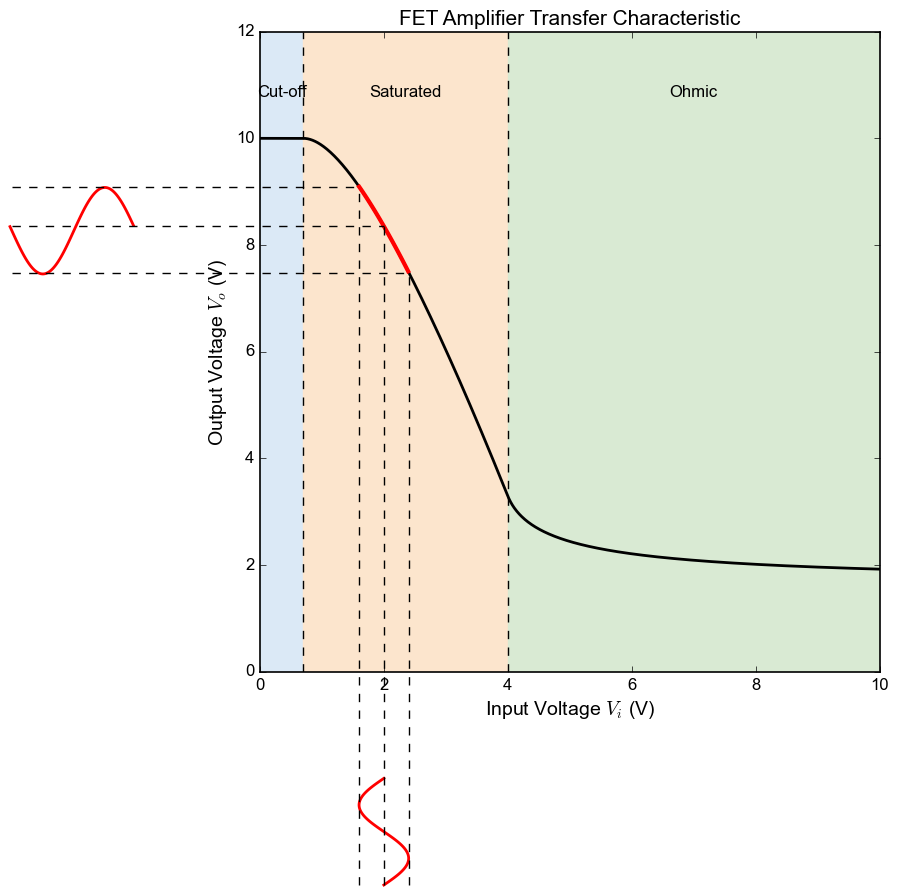

In [192]:
plt.figure(figsize=(8,8))

plt.axvspan(0, Vt, color='#dbe9f6')
plt.axvspan(Vt, Vimax, color='#fce5cd')
plt.axvspan(Vimax, 10, color='#d9ead3')
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.plot(Vi, Vo, lw=2, color='black', zorder=2)

y_in = np.linspace(-4, -2, 100)
x_in = 2 + 0.4*np.sin(y_in*2*np.pi/2)

plt.plot(Vi[np.argmin(np.abs(Vi - 1.6)):np.argmin(np.abs(Vi - 2.4))], Vo[np.argmin(np.abs(Vi - 1.6)):np.argmin(np.abs(Vi - 2.4))], color="red", ls="-", linewidth=3)
plt.plot(x_in, y_in, color="red", linewidth=2, clip_on=False)
plt.plot([2, 2], [-4, Vo[np.argmin(np.abs(Vi - 2))]], color="black", ls="--", linewidth=1, clip_on=False)
plt.plot([1.6, 1.6], [-4, Vo[np.argmin(np.abs(Vi - 1.6))]], color="black", ls="--", linewidth=1, clip_on=False)
plt.plot([2.4, 2.4], [-4, Vo[np.argmin(np.abs(Vi - 2.4))]], color="black", ls="--", linewidth=1, clip_on=False)

x_out = np.linspace(-4.03, -2.04, 100)
y_out = Vo[np.argmin(np.abs(Vi - 2))] - 0.08 + A[np.argmin(np.abs(Vi - 2))]* 0.4*np.sin(x_out*2*np.pi/2)
plt.plot(x_out, y_out, color="red", linewidth=2, clip_on=False)
plt.plot([-4, Vi[np.argmin(np.abs(Vi - 2))]], [Vo[np.argmin(np.abs(Vi - 2))],Vo[np.argmin(np.abs(Vi - 2))]] , color="black", ls="--", linewidth=1, clip_on=False)
plt.plot([-4, Vi[np.argmin(np.abs(Vi - 2.4))]], [Vo[np.argmin(np.abs(Vi - 2.4))],Vo[np.argmin(np.abs(Vi - 2.4))]] , color="black", ls="--", linewidth=1, clip_on=False)
plt.plot([-4, Vi[np.argmin(np.abs(Vi - 1.6))]], [Vo[np.argmin(np.abs(Vi - 1.6))],Vo[np.argmin(np.abs(Vi - 1.6))]] , color="black", ls="--", linewidth=1, clip_on=False)

plt.text(Vt / 2, 11, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, 11, 'Saturated', ha='center', va='top')
plt.text((Vimax + 10) / 2, 11, 'Ohmic', ha='center', va='top')
plt.xlabel(r'Input Voltage $V_i$ (V)', fontsize=14)
plt.ylabel(r'Output Voltage $V_o$ (V)', fontsize=14)
plt.xlim(0, 10)
plt.ylim(0, 12)
plt.title('FET Amplifier Transfer Characteristic', fontsize=15)
# plt.savefig("Signal-amplifier.eps", format='eps', bbox_inches='tight')
plt.show()